# 04 — EfficientNet-B0 (Proposed Model)
**BTL IS54A — Người 4**

Mô hình đề xuất chính của dự án — cân bằng tốt nhất giữa accuracy và chi phí tính toán nhờ **Compound Scaling**.

- **Phase 1**: Pre-train trên AffectNet (8 lớp cảm xúc, subset 1500/class)
- **Phase 2**: Fine-tune trên Student Engagement Dataset (6 lớp trạng thái)

Mỗi phase gồm 2 stage: Freeze (5 epochs, lr=1e-3) → Unfreeze (10 epochs, lr=1e-5).

**Yêu cầu:** GPU T4 (Colab Free), runtime ~55–65 phút.

---
**Output deliverables:**
- `BTL/weights/efficientnet_phase1.h5`
- `BTL/weights/efficientnet_phase2.h5`
- `BTL/results/efficientnet_metrics.json`
- `BTL/results/efficientnet_confusion_matrix.png`

## Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/models')

import tensorflow as tf
print(f'TF version : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
%%writefile /content/drive/MyDrive/ProjectBTL/BTL/models/efficientnet.py
"""efficientnet.py"""
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

BACKBONE_NAME = "efficientnetb0"


def build_model(num_classes, input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape, name="input_image")
    x_for_backbone = layers.Rescaling(
        scale=[0.229 * 255.0, 0.224 * 255.0, 0.225 * 255.0],
        offset=[0.485 * 255.0, 0.456 * 255.0, 0.406 * 255.0],
        name="denorm_to_0_255",
    )(inputs)
    backbone = EfficientNetB0(input_shape=input_shape, include_top=False, weights="imagenet")
    x = backbone(x_for_backbone, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.2, name="dropout_2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return Model(inputs, outputs, name=f"EfficientNetB0_FER_{num_classes}cls")


def freeze_backbone(model):
    backbone = model.get_layer(BACKBONE_NAME)
    backbone.trainable = False
    n = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"[efficientnet] Backbone FROZEN — trainable params: {n:,}")


def unfreeze_backbone(model):
    backbone = model.get_layer(BACKBONE_NAME)
    backbone.trainable = True
    n = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"[efficientnet] Backbone UNFROZEN — trainable params: {n:,}")


def load_phase1_weights_for_phase2(model_p2, p1_weights_path):
    model_p1 = build_model(num_classes=8)
    model_p1.load_weights(p1_weights_path)
    print(f"[efficientnet] Loaded Phase 1 weights từ {p1_weights_path}")
    for layer_name in [BACKBONE_NAME, "dense_256"]:
        weights = model_p1.get_layer(layer_name).get_weights()
        model_p2.get_layer(layer_name).set_weights(weights)
        print(f"[efficientnet]   Copied weights: {layer_name}")
    print(f"[efficientnet] Layer 'predictions' (6 class) giữ random init.")

Overwriting /content/drive/MyDrive/ProjectBTL/BTL/models/efficientnet.py


## Cell 2 — Đường dẫn + Import

In [9]:
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'
WEIGHTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/weights'
RESULTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/results'

from preprocess import init_mtcnn
init_mtcnn()

from dataset_affectnet import build_affectnet_dataset
from dataset_student   import build_student_dataset

from efficientnet import (
    build_model,
    freeze_backbone,
    unfreeze_backbone,
    load_phase1_weights_for_phase2,
)
print('Imports OK')

Imports OK


## Cell 3 — Copy AffectNet sang local SSD (BẮT BUỘC để training nhanh)

Đọc trực tiếp từ Drive → 8s/step. Copy về `/content/` → ~150ms/step.

In [10]:
import shutil, os

if not os.path.exists('/content/affectnet_local'):
    print('Copying AffectNet → /content/affectnet_local/ ...')
    shutil.copytree(AFFECTNET_DIR, '/content/affectnet_local')
    print('Copy xong!')
else:
    print('Đã tồn tại, bỏ qua copy.')

!du -sh /content/affectnet_local

AFFECTNET_DIR = '/content/affectnet_local'
print(f'\nAFFECTNET_DIR = {AFFECTNET_DIR}')

Đã tồn tại, bỏ qua copy.
388M	/content/affectnet_local

AFFECTNET_DIR = /content/affectnet_local


---
# 🚀 PHASE 1 — Pre-train trên AffectNet (8 class)

## Cell 4 — Build dataset

In [11]:
train_ds, class_weights = build_affectnet_dataset(
    split='train', data_dir=AFFECTNET_DIR,
    batch_size=32, subset_per_class=1500
)
test_ds, _ = build_affectnet_dataset(
    split='test', data_dir=AFFECTNET_DIR, batch_size=32
)

print('\nclass_weights:')
for idx, w in sorted(class_weights.items()):
    print(f'  Class {idx}: weight = {w:.4f}')

[dataset_affectnet] train: 11729 ảnh
[dataset_affectnet] test: 14518 ảnh

class_weights:
  Class 0: weight = 0.9774
  Class 1: weight = 0.9774
  Class 2: weight = 1.1929
  Class 3: weight = 0.9774
  Class 4: weight = 0.9774
  Class 5: weight = 0.9774
  Class 6: weight = 0.9774
  Class 7: weight = 0.9774


## Cell 5 — Build model + Freeze backbone

In [12]:
model_p1 = build_model(num_classes=8)
freeze_backbone(model_p1)

model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_p1.summary()

[efficientnet] Backbone FROZEN — trainable params: 329,992


Model: "EfficientNetB0_FER_8cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denorm_to_0_255 (Rescaling)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Cell 6 — Train Phase 1 (Freeze stage, 5 epochs)

In [13]:
history_p1_freeze = model_p1.fit(
    train_ds, validation_data=test_ds,
    epochs=5, class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)
print(f"\nFreeze stage final val_accuracy: {history_p1_freeze.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 218s 493ms/step - accuracy: 0.3345 - loss: 1.7071 - val_accuracy: 0.4293 - val_loss: 1.5143 - learning_rate: 0.0010
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 146s 399ms/step - accuracy: 0.4056 - loss: 1.5354 - val_accuracy: 0.4517 - val_loss: 1.4801 - learning_rate: 0.0010
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 143s 391ms/step - accuracy: 0.4252 - loss: 1.4852 - val_accuracy: 0.4657 - val_loss: 1.4660 - learning_rate: 0.0010
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 144s 392ms/step - accuracy: 0.4381 - loss: 1.4491 - val_accuracy: 0.4693 - val_loss: 1.4459 - learning_rate: 0.0010
Epoch 5/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 152s 415ms/step - accuracy: 0.4505 - loss: 1.4136 - val_accuracy: 0.4712 - val_loss: 1.4502 - learning_rate: 0.0010

Freeze stage final val_accuracy: 0.4712


In [8]:
import os
os.makedirs('/content/weights_local', exist_ok=True)
model_p1.save_weights('/content/weights_local/efficientnet_phase1_backup.weights.h5')
print("Backup OK")

Backup OK


In [9]:
%%writefile /content/drive/MyDrive/ProjectBTL/BTL/models/efficientnet.py
"""efficientnet.py — EfficientNet-B0 với Rescaling fix (v3)"""
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

BACKBONE_NAME = "efficientnetb0"


def build_model(num_classes: int, input_shape: tuple = (224, 224, 3)) -> Model:
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Denormalize bằng Rescaling (JSON-serializable, không Lambda)
    x_for_backbone = layers.Rescaling(
        scale=[0.229 * 255.0, 0.224 * 255.0, 0.225 * 255.0],
        offset=[0.485 * 255.0, 0.456 * 255.0, 0.406 * 255.0],
        name="denorm_to_0_255",
    )(inputs)

    backbone = EfficientNetB0(input_shape=input_shape, include_top=False, weights="imagenet")
    x = backbone(x_for_backbone, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.2, name="dropout_2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return Model(inputs, outputs, name=f"EfficientNetB0_FER_{num_classes}cls")


def freeze_backbone(model):
    backbone = model.get_layer(BACKBONE_NAME)
    backbone.trainable = False
    n = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"[efficientnet] Backbone FROZEN — trainable params: {n:,}")


def unfreeze_backbone(model):
    backbone = model.get_layer(BACKBONE_NAME)
    backbone.trainable = True
    n = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"[efficientnet] Backbone UNFROZEN — trainable params: {n:,}")


def load_phase1_weights_for_phase2(model_p2, p1_weights_path):
    model_p1 = build_model(num_classes=8)
    model_p1.load_weights(p1_weights_path)
    print(f"[efficientnet] Loaded Phase 1 weights từ {p1_weights_path}")
    for layer_name in [BACKBONE_NAME, "dense_256"]:
        weights = model_p1.get_layer(layer_name).get_weights()
        model_p2.get_layer(layer_name).set_weights(weights)
        print(f"[efficientnet]   Copied weights: {layer_name}")
    print(f"[efficientnet] Layer 'predictions' (6 class) giữ random init.")

Overwriting /content/drive/MyDrive/ProjectBTL/BTL/models/efficientnet.py


## Cell 7 — Unfreeze + Train Phase 1 (10 epochs, lr=1e-5)

In [14]:
import os
unfreeze_backbone(model_p1)
model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)

LOCAL_CKPT = '/content/weights_local/efficientnet_phase1.weights.h5'
os.makedirs(os.path.dirname(LOCAL_CKPT), exist_ok=True)

history_p1_unfreeze = model_p1.fit(
    train_ds, validation_data=test_ds,
    epochs=10, class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=LOCAL_CKPT,
            monitor='val_accuracy', save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

# Copy lên Drive
import shutil
from google.colab import drive
shutil.copy(LOCAL_CKPT, f'{WEIGHTS_DIR}/efficientnet_phase1.weights.h5')
drive.flush_and_unmount()
drive.mount('/content/drive')

print(f"\n✅ Xong Phase 1. Best val_accuracy: "
      f"{max(history_p1_unfreeze.history['val_accuracy']):.4f}")

[efficientnet] Backbone UNFROZEN — trainable params: 4,337,540
Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.2628 - loss: 2.1783
Epoch 1: val_accuracy improved from None to 0.40040, saving model to /content/weights_local/efficientnet_phase1.weights.h5

Epoch 1: finished saving model to /content/weights_local/efficientnet_phase1.weights.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 317s 623ms/step - accuracy: 0.2937 - loss: 1.9714 - val_accuracy: 0.4004 - val_loss: 1.5906 - learning_rate: 1.0000e-05
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3475 - loss: 1.6700
Epoch 2: val_accuracy improved from 0.40040 to 0.43670, saving model to /content/weights_local/efficientnet_phase1.weights.h5

Epoch 2: finished saving model to /content/weights_local/efficientnet_phase1.weights.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 178s 486ms/step - accuracy: 0.3649 - loss: 1.6282 - val_accuracy: 0.4367 - val_loss: 1.5410 - learning_rate: 1.0000e-05
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━

---
# 🎯 PHASE 2 — Fine-tune trên Student Engagement (6 class)

## Cell 8 — Build dataset Phase 2

In [15]:
train_student = build_student_dataset('train', DATA_DIR, batch_size=16)
val_student   = build_student_dataset('val',   DATA_DIR, batch_size=16)
test_student  = build_student_dataset('test',  DATA_DIR, batch_size=16)
print('\n✅ Dataset Phase 2 sẵn sàng (Student Engagement, 6 class)')

[dataset_student] train: 1484 ảnh
label
Looking Away    296
Confused        258
Frustrated      252
Bored           251
Focused         243
Drowsy          184
[dataset_student] val: 318 ảnh
label
Looking Away    64
Confused        56
Frustrated      54
Bored           53
Focused         52
Drowsy          39
[dataset_student] test: 318 ảnh
label
Looking Away    63
Confused        55
Bored           54
Frustrated      54
Focused         52
Drowsy          40

✅ Dataset Phase 2 sẵn sàng (Student Engagement, 6 class)


In [21]:
model_p2 = build_model(num_classes=6)
load_phase1_weights_for_phase2(
    model_p2, f'{WEIGHTS_DIR}/efficientnet_phase1.weights.h5'
)

freeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_p2.summary()

[efficientnet] Loaded Phase 1 weights từ /content/drive/MyDrive/ProjectBTL/BTL/weights/efficientnet_phase1.weights.h5
[efficientnet]   Copied weights: efficientnetb0
[efficientnet]   Copied weights: dense_256
[efficientnet] Layer 'predictions' (6 class) giữ random init.
[efficientnet] Backbone FROZEN — trainable params: 329,478


Model: "EfficientNetB0_FER_6cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denorm_to_0_255 (Rescaling)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Insert Cell A — Pre-extract crops

In [22]:
import os
import cv2
import pandas as pd
from pathlib import Path
from preprocess import init_mtcnn, _try_mtcnn_crop

init_mtcnn()

SRC_BASE = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DST_BASE = '/content/student_cropped'
os.makedirs(DST_BASE, exist_ok=True)

def crop_and_save(src_path, dst_path):
    img = cv2.imread(src_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cropped = _try_mtcnn_crop(img_rgb, margin=0.10)
    if cropped is None:
        cropped = img_rgb
    cropped = cv2.resize(cropped, (224, 224))
    cv2.imwrite(dst_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))

for split in ['train', 'val', 'test']:
    csv_in  = f'{DATA_DIR}/student_{split}.csv'
    csv_out = f'/content/student_{split}_cropped.csv'
    df = pd.read_csv(csv_in)
    new_paths = []

    for i, row in df.iterrows():
        src = row['filepath']
        rel = Path(src).relative_to(SRC_BASE)
        dst = Path(DST_BASE) / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            crop_and_save(src, str(dst))
        new_paths.append(str(dst))
        if i % 200 == 0:
            print(f'  [{split}] {i}/{len(df)}')

    df['filepath'] = new_paths
    df.to_csv(csv_out, index=False)
    print(f'✅ Xong {split}: {len(df)} ảnh')

print('\n✅ Pre-extract xong tất cả crops.')

  [train] 0/1484
  [train] 200/1484
[preprocess] MTCNN error: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)
  [train] 400/1484
  [train] 600/1484
  [train] 800/1484
  [train] 1000/1484
  [train] 1200/1484
  [train] 1400/1484
✅ Xong train: 1484 ảnh
  [val] 0/318
  [val] 200/318
✅ Xong val: 318 ảnh
  [test] 0/318
  [test] 200/318
✅ Xong test: 318 ảnh

✅ Pre-extract xong tất cả crops.


Insert Cell B — Build dataset cached

In [23]:
import tensorflow as tf
import pandas as pd
from augmentation import augment_train, augment_val
from preprocess import normalize_imagenet

STUDENT_LABEL_MAP = {
    "Focused": 0, "Confused": 1, "Frustrated": 2,
    "Bored": 3, "Drowsy": 4, "Looking Away": 5
}

def build_student_cached(split, batch_size=16):
    csv_path = f'/content/student_{split}_cropped.csv'
    df = pd.read_csv(csv_path)
    df['label_idx'] = df['label'].map(STUDENT_LABEL_MAP)

    filepaths = df['filepath'].tolist()
    labels    = df['label_idx'].astype(int).tolist()
    is_train  = (split == 'train')

    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.clip_by_value(img, 0.0, 1.0)
        img.set_shape([224, 224, 3])
        if is_train:
            img = augment_train(img)
        img = normalize_imagenet(img)
        return img, tf.one_hot(label, 6)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if is_train:
        ds = ds.shuffle(len(filepaths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_student = build_student_cached('train', batch_size=16)
val_student   = build_student_cached('val',   batch_size=16)
test_student  = build_student_cached('test',  batch_size=16)
print('✅ Datasets sẵn sàng')

✅ Datasets sẵn sàng


## Cell 10 — Train Phase 2 (Freeze 5 epochs → Unfreeze 10 epochs)

In [24]:
import os

# Stage 1: Freeze
history_p2_freeze = model_p2.fit(
    train_student, validation_data=val_student, epochs=5,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

# Stage 2: Unfreeze
unfreeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)

LOCAL_CKPT_P2 = '/content/weights_local/efficientnet_phase2.weights.h5'

history_p2_unfreeze = model_p2.fit(
    train_student, validation_data=val_student, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=LOCAL_CKPT_P2,
            monitor='val_accuracy', save_best_only=True,
            save_weights_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

# Copy lên Drive
import shutil
from google.colab import drive
shutil.copy(LOCAL_CKPT_P2, f'{WEIGHTS_DIR}/efficientnet_phase2.weights.h5')
drive.flush_and_unmount()
drive.mount('/content/drive')

print(f"\n✅ Xong Phase 2. Best val_accuracy: "
      f"{max(history_p2_unfreeze.history['val_accuracy']):.4f}")

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 74s 468ms/step - accuracy: 0.7763 - loss: 0.6220 - val_accuracy: 0.9403 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9030 - loss: 0.2462 - val_accuracy: 0.9591 - val_loss: 0.1623 - learning_rate: 0.0010
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9306 - loss: 0.1848 - val_accuracy: 0.9560 - val_loss: 0.1240 - learning_rate: 0.0010
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9375 - loss: 0.1415
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9306 - loss: 0.1605 - val_accuracy: 0.9340 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9414 - loss: 0.1514 - val_accuracy: 0.9654 - val_loss: 0.1195 - learning_rate: 5.0000e-04
[efficientnet] Backbone UNFROZEN — trainable params: 4,337,026
Epoch 1/10
93/93 ━━━━━━━━━━━━━━

---
# 📊 Evaluation & Save Results

## Cell 11 — Metrics + Confusion Matrix

              precision    recall  f1-score   support

     Focused       1.00      1.00      1.00        52
    Confused       1.00      1.00      1.00        55
  Frustrated       0.98      1.00      0.99        54
       Bored       0.94      0.85      0.89        54
      Drowsy       0.84      0.93      0.88        40
Looking Away       1.00      1.00      1.00        63

    accuracy                           0.97       318
   macro avg       0.96      0.96      0.96       318
weighted avg       0.97      0.97      0.97       318


✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/efficientnet_metrics.json


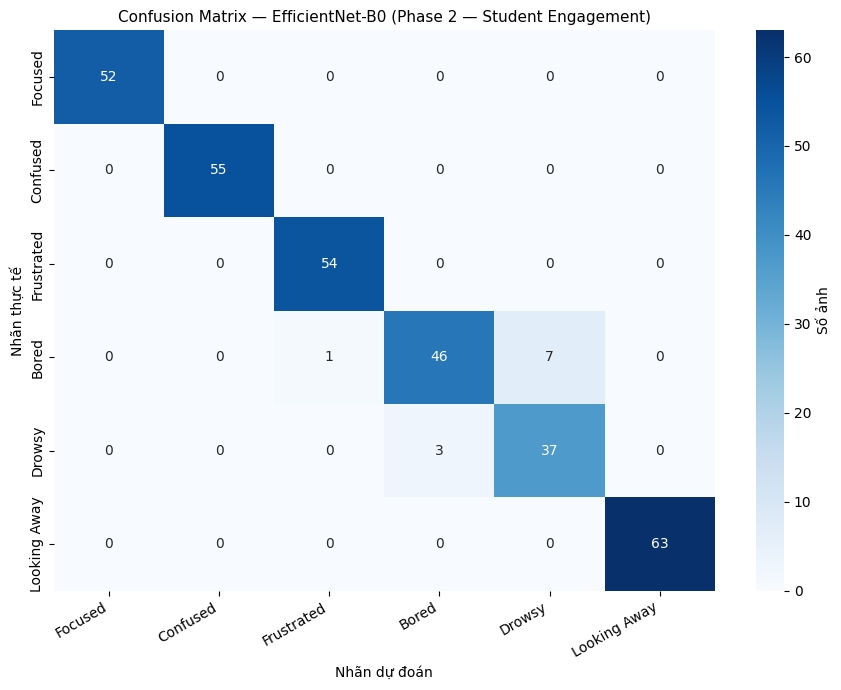

✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/efficientnet_confusion_matrix.png


In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for images, labels in test_student:
    preds = model_p2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

label_names = ['Focused', 'Confused', 'Frustrated',
                'Bored', 'Drowsy', 'Looking Away']
report = classification_report(
    y_true, y_pred, target_names=label_names, output_dict=True
)
print(classification_report(y_true, y_pred, target_names=label_names))

metrics = {
    'model': 'EfficientNetB0',
    'phase1_best_val_acc': float(max(history_p1_unfreeze.history['val_accuracy'])),
    'phase2_accuracy':     float(report['accuracy']),
    'macro_f1':            float(report['macro avg']['f1-score']),
    'precision':           float(report['macro avg']['precision']),
    'recall':              float(report['macro avg']['recall']),
    'per_class_f1':        {n: float(report[n]['f1-score']) for n in label_names},
    'per_class_precision': {n: float(report[n]['precision']) for n in label_names},
    'per_class_recall':    {n: float(report[n]['recall']) for n in label_names},
}
with open(f'{RESULTS_DIR}/efficientnet_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\n✅ Lưu: {RESULTS_DIR}/efficientnet_metrics.json")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Số ảnh'})
plt.title('Confusion Matrix — EfficientNet-B0 (Phase 2 — Student Engagement)', fontsize=11)
plt.ylabel('Nhãn thực tế'); plt.xlabel('Nhãn dự đoán')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/efficientnet_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Lưu: {RESULTS_DIR}/efficientnet_confusion_matrix.png")

## Bonus — Training curves

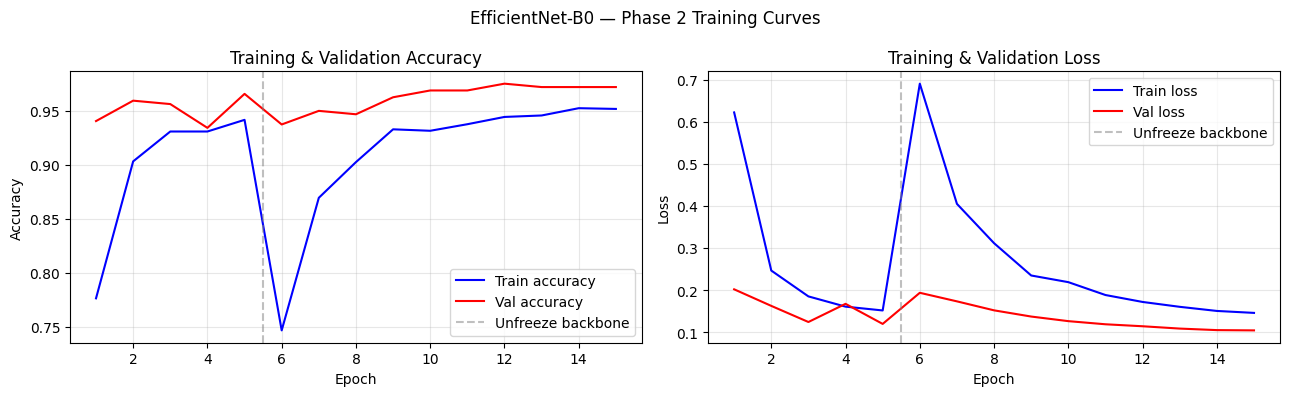

✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/efficientnet_training_curves.png


In [26]:
acc_train = (history_p2_freeze.history['accuracy'] +
             history_p2_unfreeze.history['accuracy'])
acc_val   = (history_p2_freeze.history['val_accuracy'] +
             history_p2_unfreeze.history['val_accuracy'])
loss_train = (history_p2_freeze.history['loss'] +
              history_p2_unfreeze.history['loss'])
loss_val   = (history_p2_freeze.history['val_loss'] +
              history_p2_unfreeze.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(acc_train) + 1)

axes[0].plot(epochs, acc_train, 'b-', label='Train accuracy')
axes[0].plot(epochs, acc_val,   'r-', label='Val accuracy')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze backbone')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & Validation Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, loss_train, 'b-', label='Train loss')
axes[1].plot(epochs, loss_val,   'r-', label='Val loss')
axes[1].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze backbone')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Phase 2 Training Curves', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/efficientnet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Lưu: {RESULTS_DIR}/efficientnet_training_curves.png")

---
## ✅ Hoàn thành — Checklist nộp

| File | Vị trí |
|------|--------|
| ✅ `efficientnet_phase1.h5` | `BTL/weights/` |
| ✅ `efficientnet_phase2.h5` | `BTL/weights/` |
| ✅ `efficientnet_metrics.json` | `BTL/results/` |
| ✅ `efficientnet_confusion_matrix.png` | `BTL/results/` |
| ✅ `efficientnet_training_curves.png` | `BTL/results/` |

**Word còn lại của Người 4 (không trong notebook này):**
- Khung Chương 3 chung: 3.1, 3.2 (pipeline), 3.3 (data split), 3.5 (cài đặt), 3.7 (framework)
- Mục 3.4.3: mô tả EfficientNet-B0 (Compound Scaling)
- Gửi số liệu cho Người 5